# Training the Swin Transformer for Colorectal Cancer WSI Classification

In [1]:
import os
import kagglehub
import shutil
import pandas as pd
import tqdm as notebook_tqdm
from utils import build_dataset_from_csv

KAGGLE_DATASET_NAME = "mahdiislam/colorectal-cancer-wsi"
KAGGLE_DATASET_PATH = kagglehub.dataset_download(KAGGLE_DATASET_NAME)
KAGGLE_DATASET_PATH = os.path.join(KAGGLE_DATASET_PATH, "EBHI-SEG")

/home/aletyska/anaconda3/envs/crc_wsi_classification/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
build_dataset_from_csv(KAGGLE_DATASET_PATH)

-------------------------------------------------
-------- Start Building dataset from CSV --------
-------------------------------------------------
-------- Current dataset folder structure --------
EBHI-SEG/
    val/
        High-grade IN/
        Low-grade IN/
        Serrated adenoma/
        Normal/
        Polyp/
        Adenocarcinoma/
    train/
        High-grade IN/
        Low-grade IN/
        Serrated adenoma/
        Normal/
        Polyp/
        Adenocarcinoma/
-------- Changing dataset folder structure --------
Processing: val
Processing: train

Restructuring complete.
-------- Organizing dataset into train/val --------
Processing train split from /home/aletyska/repos/crc_wsi_classification/src/datasets/train_paths.csv...
Processing val split from /home/aletyska/repos/crc_wsi_classification/src/datasets/val_paths.csv...
Organization complete.
-------- Current dataset folder structure --------
EBHI-SEG/
    val/
        High-grade IN/
        Low-grade IN/
        Serr

In [3]:
from torchvision.datasets import ImageFolder
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models

BATCH_SIZE = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

weights = models.Swin_T_Weights.IMAGENET1K_V1
transforms_compose = weights.transforms()

print(f"Using transforms: {transforms_compose}")

train_dataset = ImageFolder(KAGGLE_DATASET_PATH + '/train', transform=transforms_compose)
val_dataset = ImageFolder(KAGGLE_DATASET_PATH + '/val', transform=transforms_compose)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train DataLoader created with batch size: {BATCH_SIZE}")
print(f"Validation DataLoader created with batch size: {BATCH_SIZE}")

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
print(f"Classes: {class_names}")

Using device: cuda
Using transforms: ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
Train DataLoader created with batch size: 16
Validation DataLoader created with batch size: 16
Classes: ['Adenocarcinoma', 'High-grade IN', 'Low-grade IN', 'Normal', 'Polyp', 'Serrated adenoma']


In [4]:
model = models.swin_t(weights=weights)

num_classes = len(class_names)

in_features = model.head.in_features
model.head = nn.Linear(in_features, num_classes)

model = model.to(device)

print(f"Swin-Tiny model loaded and adapted for {num_classes} classes.")

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

NUM_EPOCHS = 10
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /home/aletyska/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:04<00:00, 28.3MB/s] 


Swin-Tiny model loaded and adapted for 6 classes.


In [5]:
def train_model(model, train_dataloader, criterion, optimizer, scheduler, num_epochs):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        
        print(f"Epoch {epoch+1}/{num_epochs}")

        pbar = notebook_tqdm.tqdm(train_dataloader, desc=f"Epoch {epoch+1}")
        
        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            
            pbar.set_postfix({'Loss': loss.item()})
        
        scheduler.step()
        
        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples
        current_lr = scheduler.get_last_lr()[0]
        
        print(f"Epoch {epoch+1} Summary - Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - LR: {current_lr:.6f}")

In [6]:
train_model(model, train_dataloader, criterion, optimizer, scheduler, NUM_EPOCHS)

Epoch 1/10


Epoch 1: 100%|██████████| 112/112 [00:28<00:00,  3.86it/s, Loss=0.548]


Epoch 1 Summary - Loss: 0.6619 - Accuracy: 0.7699 - LR: 0.000098
Epoch 2/10


Epoch 2: 100%|██████████| 112/112 [00:27<00:00,  4.11it/s, Loss=1.12] 


Epoch 2 Summary - Loss: 0.3323 - Accuracy: 0.8799 - LR: 0.000090
Epoch 3/10


...

Epoch 8 Summary - Loss: 0.0187 - Accuracy: 0.9966 - LR: 0.000010
Epoch 9/10


Epoch 9: 100%|██████████| 112/112 [00:27<00:00,  4.03it/s, Loss=0.0778] 


Epoch 9 Summary - Loss: 0.0187 - Accuracy: 0.9966 - LR: 0.000002
Epoch 10/10


Epoch 10: 100%|██████████| 112/112 [00:27<00:00,  4.11it/s, Loss=0.00316] 

Epoch 10 Summary - Loss: 0.0132 - Accuracy: 0.9989 - LR: 0.000000


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Metrics
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Classification Report:
                  precision    recall  f1-score   support

  Adenocarcinoma       0.92      0.98      0.95       158
   High-grade IN       0.88      0.67      0.76        43
    Low-grade IN       0.91      0.95      0.93       132
          Normal       0.77      0.83      0.80        12
           Polyp       0.96      0.88      0.92        92
Serrated adenoma       1.00      1.00      1.00         9

        accuracy                           0.92       446
       macro avg       0.91      0.89      0.89       446
    weighted avg       0.92      0.92      0.92       446



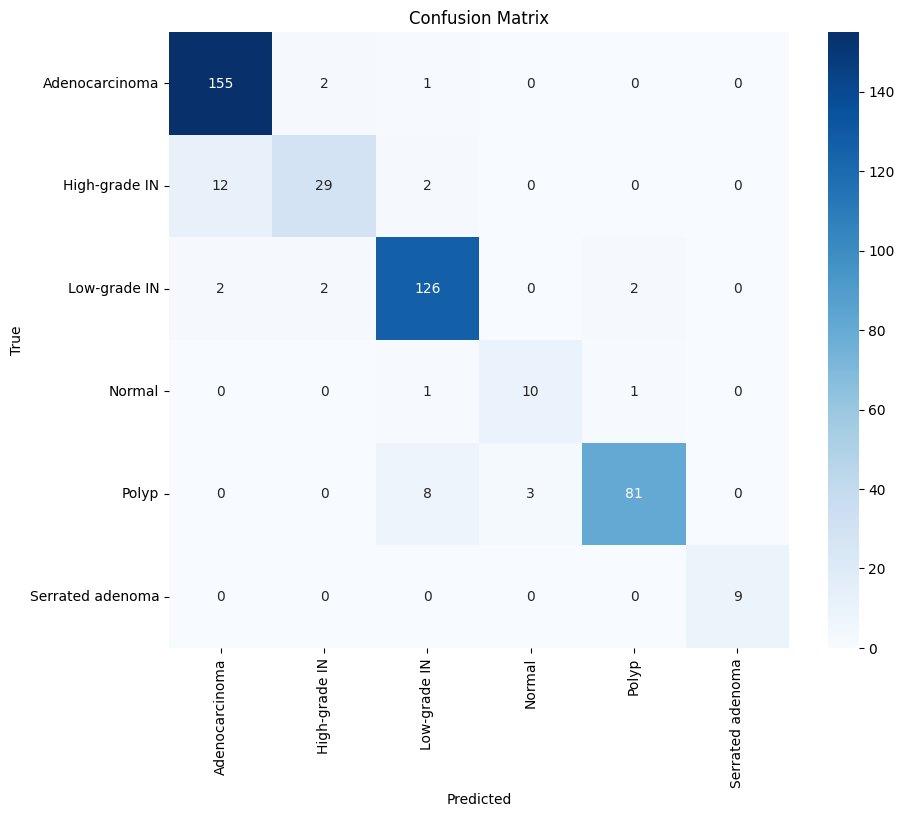

In [8]:
evaluate_model(model, val_dataloader, class_names)